# Chapter 30: External Data and Leakage

**How far does a validation score built on revised data drift from deployment, and when does the training join start to cost accuracy too?**

Adjusted and revised sources are common, and joining them by event date is the default of most merge code. The validation score then describes data that did not exist at prediction time, and the model learns to trust it too much.

*Constructed series with declared release and revision schedules; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

One hundred constructed series, each with 300 months of 30 daily rows. A monthly indicator follows a persistent process; its first release comes 10 days after the month ends with noise of the control size (standard deviation, the true indicator has standard deviation 1.0), and a revision 15 days later is close to the truth. Each daily row is about the month that just ended, and its label depends on that month's true value plus an internal feature. A ridge regression is trained on months 0 to 99 and validated on months 100 to 139. The event-date join uses the revised value for every row; the as-of join uses the latest version of the latest period published at the row's cutoff. Both models are then scored on months 140 to 299 (4,800 rows) with the as-of join, the only data that exist at prediction time.

In [1]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

from kaggle_companion.activities._common import clean

SEED = 30
REPLICATES = 100        # independent constructed series; every estimate is their mean
MONTHS, DAYS = 300, 30  # 300 months of 30 daily rows each
TRAIN_END, VALID_END = 100, 140   # months 0-99 train, 100-139 validate, 140-299 are the deployment period
LAG, REVISION_DELAY = 10, 15      # first release 10 days after the period ends, revised 15 days later
REVISED_SD = 0.1                  # the revised value is close to the truth, whatever the first release was


def generate(first_release_sd, seed):
    """A monthly indicator with a first release (noisy) and a later revision (close to the truth), and daily rows.
    Each daily row concerns the month that just ended, so its label depends on that month's true indicator."""
    rng = np.random.default_rng(seed)
    truth = np.zeros(MONTHS)
    for m in range(1, MONTHS):
        truth[m] = 0.6 * truth[m - 1] + rng.normal(0, 0.8)
    first = truth + rng.normal(0, first_release_sd, MONTHS)
    revised = truth + rng.normal(0, REVISED_SD, MONTHS)

    t = np.arange(MONTHS * DAYS)                    # absolute day of each row: the row's prediction cutoff
    month = t // DAYS
    period = np.maximum(month - 1, 0)               # the indicator period the row is about
    own = rng.normal(size=len(t))                   # a feature known inside the table
    y = truth[period] + 0.5 * own + rng.normal(0, 0.7, len(t))

    # Event-date join: the revised value of the row's period, which exists only weeks after the cutoff.
    event_date = revised[period]
    # As-of join: for each row, the latest period whose first release is out by the cutoff, in its latest published version.
    as_of = np.zeros(len(t))
    for age in (0, 1):                              # try the row's own period, then the one before it
        p = np.maximum(period - age, 0)
        released = DAYS * (p + 1) + LAG <= t
        revised_out = DAYS * (p + 1) + LAG + REVISION_DELAY <= t
        value = np.where(revised_out, revised[p], first[p])
        as_of = np.where(released & (as_of == 0), value, as_of)   # 0 means nothing eligible found yet
    return month, np.column_stack([own, event_date]), np.column_stack([own, as_of]), y


def one_series(first_release_sd, seed):
    month, X_event, X_asof, y = generate(first_release_sd, seed)
    train, valid, deploy = month < TRAIN_END, (month >= TRAIN_END) & (month < VALID_END), month >= VALID_END
    out = {}
    # Event-date pipeline: train and validate on revised values, then deploy where only as-of values exist.
    model = Ridge(1.0).fit(X_event[train], y[train])
    out["event_valid"] = r2_score(y[valid], model.predict(X_event[valid]))
    out["event_deploy"] = r2_score(y[deploy], model.predict(X_asof[deploy]))
    # As-of pipeline: the same point-in-time join in training, validation and deployment.
    model = Ridge(1.0).fit(X_asof[train], y[train])
    out["asof_valid"] = r2_score(y[valid], model.predict(X_asof[valid]))
    out["asof_deploy"] = r2_score(y[deploy], model.predict(X_asof[deploy]))
    return out


def run(first_release_sd):
    series = [one_series(first_release_sd, SEED * 1000 + i) for i in range(REPLICATES)]
    keys = ["event_valid", "event_deploy", "asof_valid", "asof_deploy"]
    return clean({
        "first_release_sd": first_release_sd,
        **{k: float(np.mean([s[k] for s in series])) for k in keys},
        "sd": {k: float(np.std([s[k] for s in series])) for k in keys},
        "replicates": REPLICATES, "lag_days": LAG, "revision_days": REVISION_DELAY,
        "deployment_rows": (MONTHS - VALID_END) * DAYS,
    })


## Measure it across the control

The control is **noise in the first release (standard deviation of its error)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch30 import explain

VALUES = [0, 0.3, 0.6, 1.0]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                              0    0.3    0.6    1.0
Event-date validation     0.691  0.691  0.691  0.691
Event-date at deployment  0.553  0.527  0.450  0.266
As-of validation          0.536  0.517  0.468  0.385
As-of at deployment       0.562  0.543  0.494  0.412
Validation inflation      0.138  0.164  0.241  0.425


## Look at it

The figure shows the default setting, noise in the first release (standard deviation of its error) = 0.6.

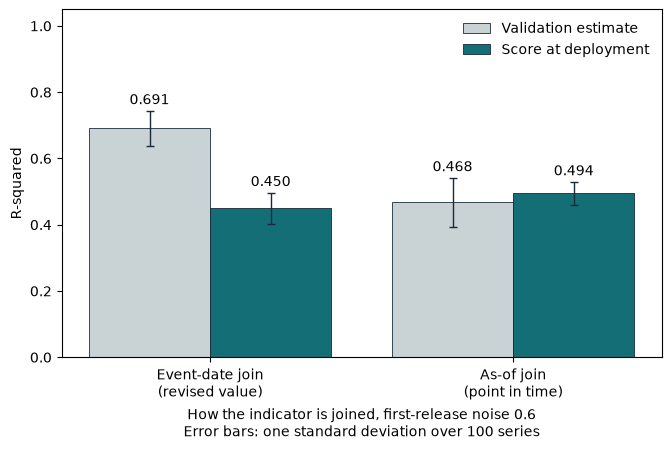

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch30 import draw, NCOLS, HEIGHT

DEFAULT = 0.6
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With first-release noise 0.6, the event-date join validates at 0.691 but scores 0.450 at deployment, 0.691 - 0.450 = 0.241 of inflation. The as-of join validates at 0.468 and scores 0.494, a difference of -0.026. Training on the event-date join also costs 0.044 of deployment R-squared (0.494 for the as-of model against 0.450).

- Event-date join: 0.691 - 0.450 = 0.241 (validation minus deployment).
- As-of join: 0.468 - 0.494 = -0.026.
- Cost of the event-date training join at deployment: 0.494 - 0.450 = +0.044.
- Spread of the as-of validation estimate over 100 series: one standard deviation is 0.074.

## Apply this to your competition

- Record both the event period and the first-publication timestamp of every external source, and keep each vintage you download.
- Join every row to the latest version published at or before its cutoff, in training and in validation, never by event date alone.
- Count rows with no eligible version and decide the fallback before modelling; do not fill them from a later revision.
- Compare the new source against the unchanged baseline on the same point-in-time folds, and keep failed joins in the log.

Book location: Chapter 30, A Version-Aware Join.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)